In [36]:
install.packages("Matching")
install.packages("rgenoud")

Installing package into ‘/home/yash/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/yash/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [20]:
install.packages("ipw")

Installing package into ‘/home/yash/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

also installing the dependency ‘geepack’




In [29]:
install.packages("kableExtra")

Installing package into ‘/home/yash/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

also installing the dependency ‘svglite’




In [30]:
library(modelsummary)
library(kableExtra)
library(MatchIt)
library(cobalt)
library(gridExtra)
library(ggplot2)
library(grid)
library(knitr)
library(rgenoud)
library(Matching)
library(ipw)

In [2]:
options(repr.plot.width = 16, repr.plot.height = 8)

# Part 2: Observational Estimation 

In [3]:
data <- read.csv("data_dengue_net_v3.csv")
names(data)

[1] "net_num"     "dengue_risk" "income"      "health"      "household"  
 [6] "temperature" "resistance"  "rainfall"    "is_eligible" "is_netUser"

## 2a. Naive model

In [4]:
# Regression on net (binary)
model1 <- lm(dengue_risk ~ is_netUser, data = data)

#Regression on net_num
model2 <- lm(dengue_risk ~ net_num, data = data)

#Regression Summary 
modelsummary(list("Binary (net)" = model1, "Count (net_num)" = model2))


+-------------+--------------+-----------------+
|             | Binary (net) | Count (net_num) |
+=============+==============+=================+
| (Intercept) | 40.920       | 39.824          |
+-------------+--------------+-----------------+
|             | (0.425)      | (0.421)         |
+-------------+--------------+-----------------+
| is_netUser  | -18.462      |                 |
+-------------+--------------+-----------------+
|             | (0.627)      |                 |
+-------------+--------------+-----------------+
| net_num     |              | -7.671          |
+-------------+--------------+-----------------+
|             |              | (0.284)         |
+-------------+--------------+-----------------+
| Num.Obs.    | 1752         | 1752            |
+-------------+--------------+-----------------+
| R2          | 0.331        | 0.294           |
+-------------+--------------+-----------------+
| R2 Adj.     | 0.331        | 0.293           |
+-------------+----

## 2b. Regressioin Adjustment

### 2b.1. Regression with and without Environmental Variables and binary treatment Variable

In [5]:
model3 <- lm(dengue_risk ~ is_netUser + household + income , data = data)
model4 <- lm(dengue_risk ~ is_netUser + temperature + rainfall + resistance + household + income, data = data)
modelsummary(list("Model w/o Env. Var" = model3, "Model w. Env. Var" = model4))


+-------------+--------------------+-------------------+
|             | Model w/o Env. Var | Model w. Env. Var |
+=============+====================+===================+
| (Intercept) | 70.581             | 47.082            |
+-------------+--------------------+-------------------+
|             | (0.603)            | (1.212)           |
+-------------+--------------------+-------------------+
| is_netUser  | -10.718            | -10.708           |
+-------------+--------------------+-------------------+
|             | (0.354)            | (0.311)           |
+-------------+--------------------+-------------------+
| household   | -0.589             | -0.614            |
+-------------+--------------------+-------------------+
|             | (0.098)            | (0.086)           |
+-------------+--------------------+-------------------+
| income      | -0.003             | -0.003            |
+-------------+--------------------+-------------------+
|             | (0.000)       

### 2b.1. Regression with and without Environmental Variables and Count treatment Variable

In [6]:
model5 <- lm(dengue_risk ~ net_num + temperature + income , data = data)
model6 <- lm(dengue_risk ~ net_num + temperature + rainfall + resistance + income, data = data)
modelsummary(list("Model w/o Env. Var" = model5, "Model w. Env. Var" = model6))


+-------------+--------------------+-------------------+
|             | Model w/o Env. Var | Model w. Env. Var |
+=============+====================+===================+
| (Intercept) | 57.205             | 45.706            |
+-------------+--------------------+-------------------+
|             | (1.046)            | (1.137)           |
+-------------+--------------------+-------------------+
| net_num     | -5.061             | -5.052            |
+-------------+--------------------+-------------------+
|             | (0.141)            | (0.128)           |
+-------------+--------------------+-------------------+
| temperature | 0.495              | 0.511             |
+-------------+--------------------+-------------------+
|             | (0.040)            | (0.037)           |
+-------------+--------------------+-------------------+
| income      | -0.003             | -0.003            |
+-------------+--------------------+-------------------+
|             | (0.000)       

## 2c. Matching

In [7]:
# Base formula — replace with your adjustment set
match_formula <- is_netUser ~ income + household

# --- Method 1: Nearest Neighbour (Mahalanobis distance) ---
m_nn <- matchit(match_formula, data = data, 
                method = "nearest", distance = "mahalanobis")

# --- Method 2: Propensity Score Matching ---
m_ps <- matchit(match_formula, data = data, 
                method = "nearest", distance = "logit")

# --- Method 3: K:1 Matching for k = 1, 2, 3, 4 ---
m_k1 <- matchit(match_formula, data = data, 
                method = "nearest", distance = "logit", ratio = 1)

m_k2 <- matchit(match_formula, data = data, 
                method = "nearest", distance = "logit", ratio = 2)

m_k3 <- matchit(match_formula, data = data, 
                method = "nearest", distance = "logit", ratio = 3)

m_k4 <- matchit(match_formula, data = data, 
                method = "nearest", distance = "logit", ratio = 4)

Warning message:
“Not all treated units will get 2 matches.”
Warning message:
“Not all treated units will get 3 matches.”
Warning message:
“Not all treated units will get 4 matches.”


In [8]:
options(repr.plot.width = 20, repr.plot.height = 6)

base_theme <- theme_minimal(base_size = 18) +
  theme(
    plot.title      = element_text(face = "bold", hjust = 0.5, size = 19),
    axis.text       = element_text(size = 16),
    axis.text.y     = element_text(size = 15),   # covariate label size
    axis.title      = element_text(size = 16),
    legend.text     = element_text(size = 14),
    legend.title    = element_text(size = 15)
  )

# --- Group 1: Method comparison ---
p_nn <- love.plot(m_nn, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "NN — Mahalanobis") + base_theme

p_ps <- love.plot(m_ps, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "Propensity Score") + base_theme

# --- Group 2: K:1 matching ---
p_k1 <- love.plot(m_k1, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "K:1 Matching (k = 1)") + base_theme

p_k2 <- love.plot(m_k2, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "K:1 Matching (k = 2)") + base_theme

p_k3 <- love.plot(m_k3, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "K:1 Matching (k = 3)") + base_theme

p_k4 <- love.plot(m_k4, threshold = 0.1, stats = "mean.diffs",
                  colors = c("#E84855", "#2E86AB"), size = 4,
                  title  = "K:1 Matching (k = 4)") + base_theme

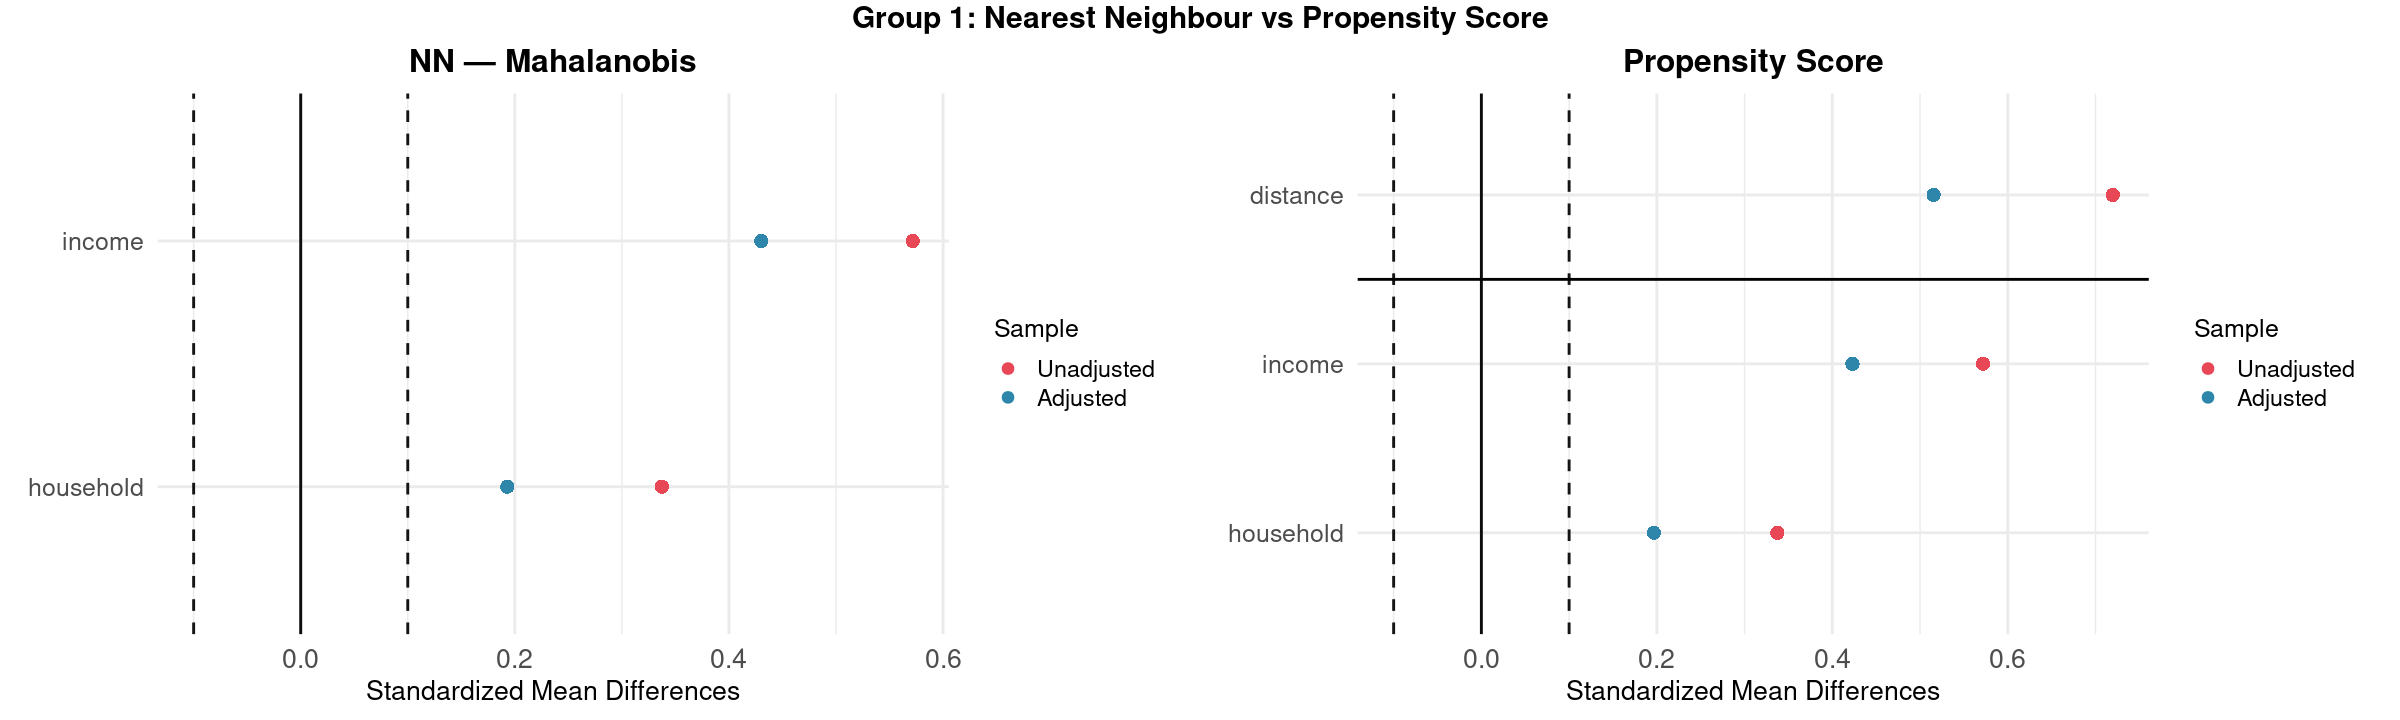

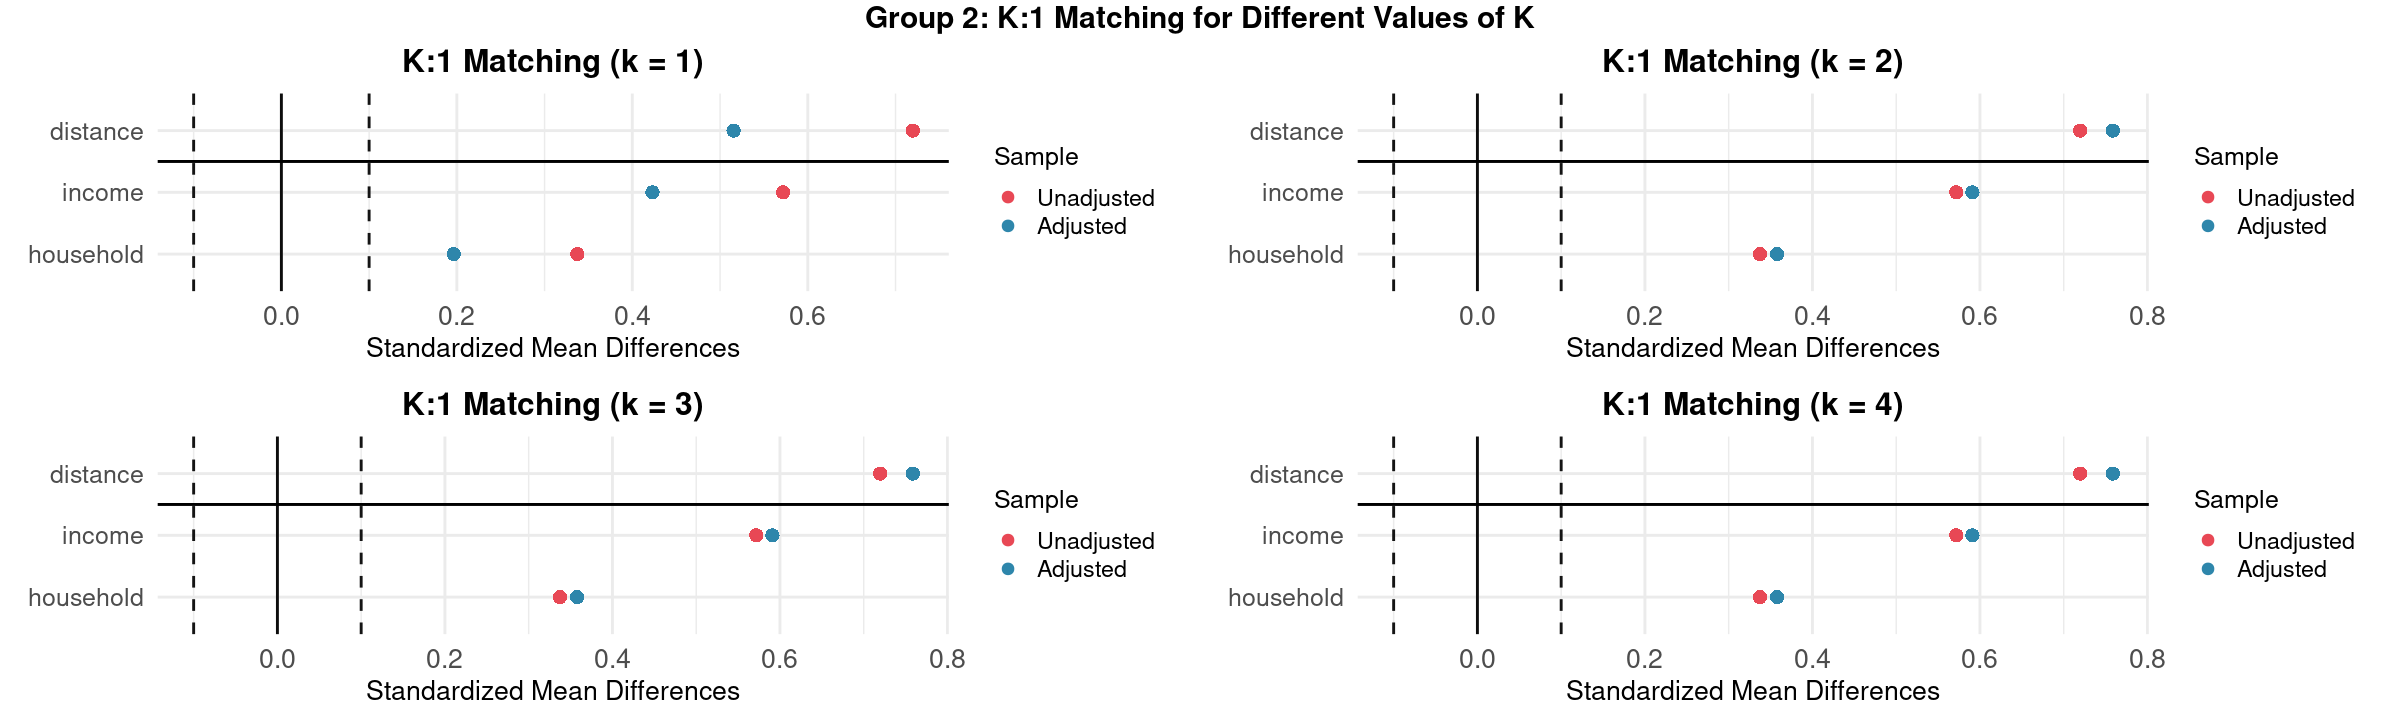

In [9]:
# --- Row 1: Method comparison ---
grid.arrange(
  p_nn, p_ps,
  ncol = 2,
  top  = textGrob("Group 1: Nearest Neighbour vs Propensity Score",
                  gp = gpar(fontsize = 18, fontface = "bold"))
)


grid.arrange(
  p_k1, p_k2, p_k3, p_k4,
  ncol = 2,
  nrow = 2,  
  top  = textGrob("Group 2: K:1 Matching for Different Values of K",
                  gp = gpar(fontsize = 18, fontface = "bold"))
)

In [10]:
# Extract sample sizes for each model
models      <- list(m_nn, m_ps, m_k1, m_k2, m_k3, m_k4)
model_names <- c("NN Mahalanobis", "Propensity Score", 
                 "K=1", "K=2", "K=3", "K=4")

ess_table <- do.call(rbind, lapply(seq_along(models), function(i) {
  nn <- summary(models[[i]])$nn
  data.frame(
    Method          = model_names[i],
    All_Control     = nn["All", "Control"],
    All_Treated     = nn["All", "Treated"],
    Matched_Control = nn["Matched", "Control"],
    Matched_Treated = nn["Matched", "Treated"],
    Unmatched       = nn["Unmatched", "Control"]
  )
}))

kable(ess_table, 
      caption = "Table: Effective Sample Sizes Across Matching Methods",
      row.names = FALSE)



Table: Table: Effective Sample Sizes Across Matching Methods

|Method           | All_Control| All_Treated| Matched_Control| Matched_Treated| Unmatched|
|:----------------|-----------:|-----------:|---------------:|---------------:|---------:|
|NN Mahalanobis   |         950|         802|             802|             802|       148|
|Propensity Score |         950|         802|             802|             802|       148|
|K=1              |         950|         802|             802|             802|       148|
|K=2              |         950|         802|             950|             802|         0|
|K=3              |         950|         802|             950|             802|         0|
|K=4              |         950|         802|             950|             802|         0|

In [17]:
#Extracting matched dataset from each model
data_nn    <- match.data(m_nn)
data_ps    <- match.data(m_ps)
data_k1    <- match.data(m_k1)
data_k2    <- match.data(m_k2)
data_k3    <- match.data(m_k3)
data_k4    <- match.data(m_k4)

#Runing regressions on matched dataset
te_nn    <- lm(dengue_risk ~ is_netUser, data = data_nn,    weights = weights)
te_ps    <- lm(dengue_risk ~ is_netUser, data = data_ps,    weights = weights)
te_k1    <- lm(dengue_risk ~ is_netUser, data = data_k1,    weights = weights)
te_k2    <- lm(dengue_risk ~ is_netUser, data = data_k2,    weights = weights)
te_k3    <- lm(dengue_risk ~ is_netUser, data = data_k3,    weights = weights)
te_k4    <- lm(dengue_risk ~ is_netUser, data = data_k4,    weights = weights)

modelsummary(
  list(
    "NN Mahalanobis"       = te_nn,
    "Propensity Score"     = te_ps,
    "K=1"                  = te_k1,
    "K=2"                  = te_k2,
    "K=3"                  = te_k3,
    "K=4"                  = te_k4
  ),
  coef_map  = c("is_netUser" = "Net Use (Binary)"),
  stars     = TRUE,
  gof_map   = c("nobs", "r.squared"),
  title     = "Table: Treatment Effect Estimates Across Matching Methods"
)


+------------------+----------------+------------------+------------+------------+------------+------------+
|                  | NN Mahalanobis | Propensity Score | K=1        | K=2        | K=3        | K=4        |
+==================+================+==================+============+============+============+============+
| Net Use (Binary) | -16.611***     | -16.501***       | -16.501*** | -18.729*** | -18.729*** | -18.729*** |
+------------------+----------------+------------------+------------+------------+------------+------------+
|                  | (0.652)        | (0.648)          | (0.648)    | (0.606)    | (0.606)    | (0.606)    |
+------------------+----------------+------------------+------------+------------+------------+------------+
| Num.Obs.         | 1604           | 1604             | 1604       | 1752       | 1752       | 1752       |
+------------------+----------------+------------------+------------+------------+------------+------------+
| R2              

## 2d. Inverse Probability Weighting Estimate

In [23]:
te_ipw <- ipwpoint(
  exposure    = is_netUser,          
  family      = "binomial",
  link        = "logit",
  numerator   = ~ 1,                 
  denominator = ~ income + household, 
  data        = data
)

summary(te_ipw$ipw.weights)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.4951  0.7247  0.8803  0.9977  1.1457  4.6860 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.4951  0.7247  0.8803  0.9977  1.1457  4.6860 

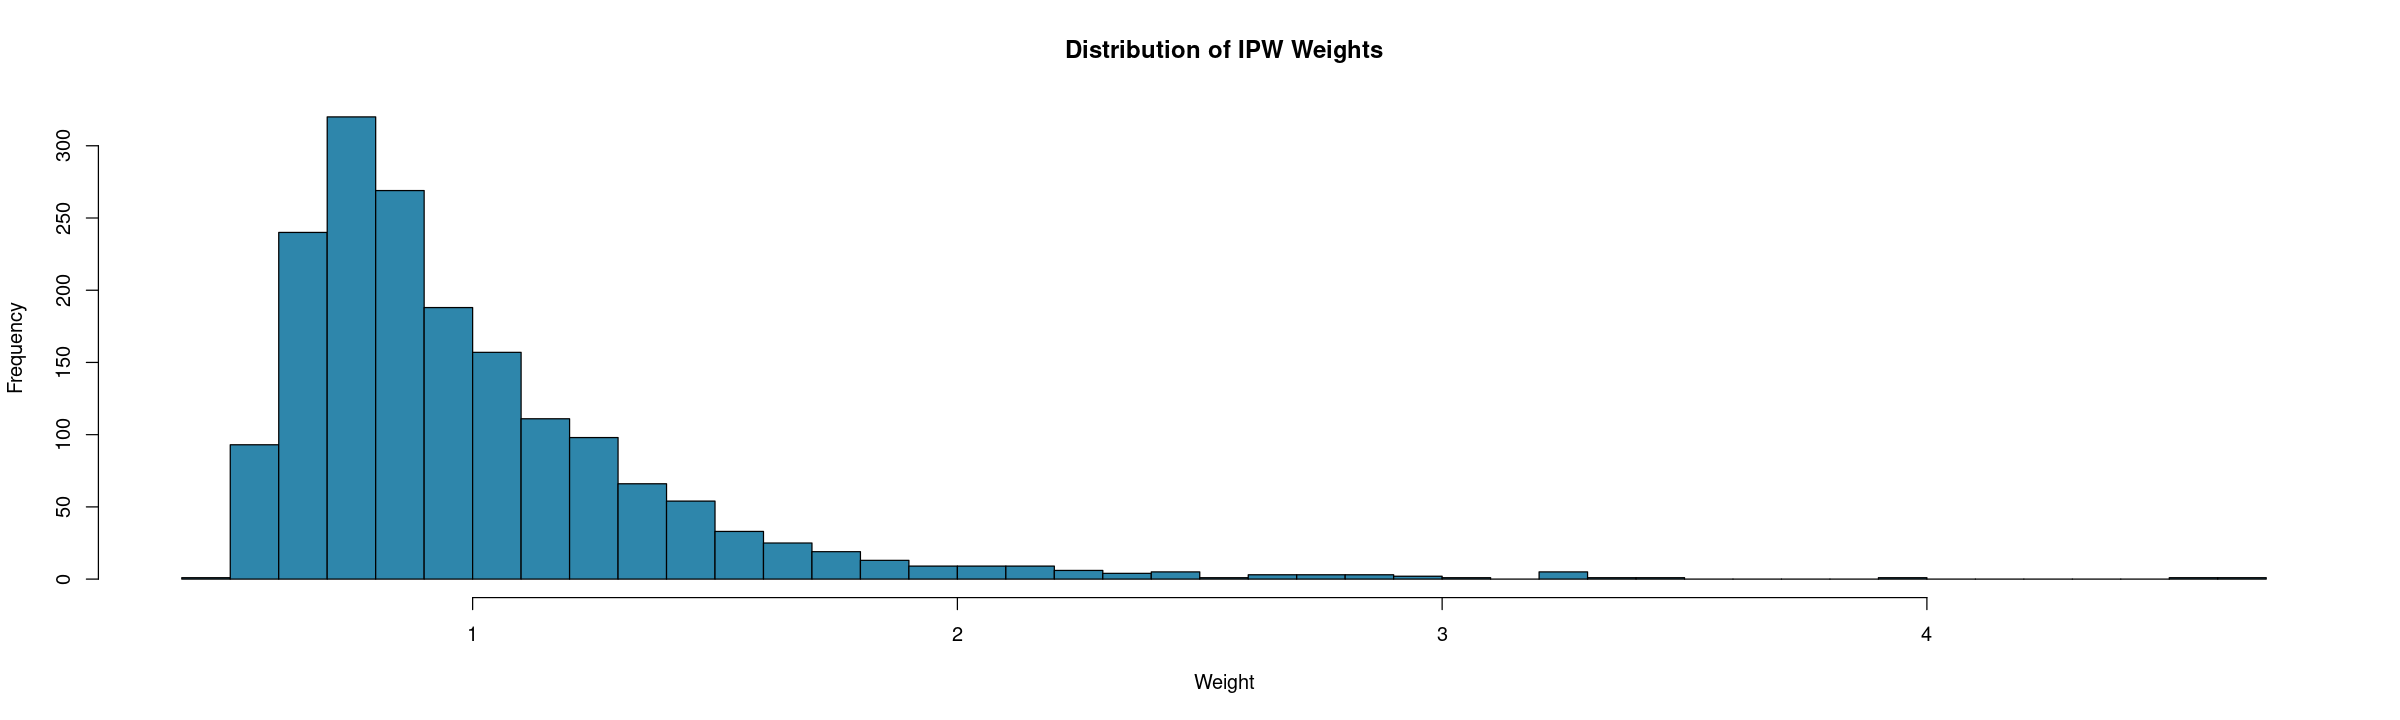

In [24]:
# Plot weight distribution
hist(te_ipw$ipw.weights, breaks = 50, 
     main = "Distribution of IPW Weights",
     xlab = "Weight", col = "#2E86AB")

summary(te_ipw$ipw.weights)

In [27]:
data$ipw_weights <- te_ipw$ipw.weights

# ATE
te_ate_ipw <- lm(dengue_risk ~ is_netUser, data = data, weights = ipw_weights)

# ATT 
data$att_weights <- ifelse(data$is_netUser == 1, 1, te_ipw$ipw.weights)
te_att_ipw <- lm(dengue_risk ~ is_netUser, data = data, weights = att_weights)

# ATU 
data$atu_weights <- ifelse(data$is_netUser == 0, 1, te_ipw$ipw.weights)
te_atu_ipw <- lm(dengue_risk ~ is_netUser, data = data, weights = atu_weights)

modelsummary(
  list(
    "ATE" = te_ate_ipw,
    "ATT" = te_att_ipw,
    "ATU" = te_atu_ipw
  ),
  coef_map = c("is_netUser" = "Net Use"),
  stars    = TRUE,
  gof_map  = c("nobs", "r.squared"),
  title    = "Table: IPW Estimates of ATE, ATT and ATU"
)


+----------+------------+------------+------------+
|          | ATE        | ATT        | ATU        |
+==========+============+============+============+
| Net Use  | -10.758*** | -15.150*** | -14.071*** |
+----------+------------+------------+------------+
|          | (0.658)    | (0.663)    | (0.622)    |
+----------+------------+------------+------------+
| Num.Obs. | 1752       | 1752       | 1752       |
+----------+------------+------------+------------+
| R2       | 0.132      | 0.230      | 0.226      |
+==========+============+============+============+
| + p < 0.1, * p < 0.05, ** p < 0.01, *** p <     |
| 0.001                                           |
+==========+============+============+============+
Table: Table: IPW Estimates of ATE, ATT and ATU 

## 2e. Summary of different matching techniques

In [38]:
library(IRdisplay)

modelsummary(
  list(
    "Binary"        = model1,
    "Count"         = model2,
    "Adjusted"      = model3,
    "NN Mahal."     = te_nn,
    "Prop. Score"   = te_ps,
    "K=1"           = te_k1,
    "K=2"           = te_k2,
    "K=3"           = te_k3,
    "K=4"           = te_k4,
    "ATE"           = te_ate_ipw,
    "ATT"           = te_att_ipw,
    "ATU"           = te_atu_ipw
  ),
  coef_map  = c("is_netUser" = "Net Use (Binary)",
                "net_num"    = "Net Use (Count)"),
  stars     = TRUE,
  gof_map   = c("nobs", "r.squared"),
  title     = "Table: Full Comparison of Treatment Effect Estimates",
  output    = "kableExtra"
) |>
add_header_above(
  c(" "                  = 1,
    "Naive OLS"          = 2,
    "Adjusted OLS (ATE)" = 1,
    "Matching (ATE)"     = 6,
    "IPW"                = 3
  )
) |>
kable_styling(
  bootstrap_options = c("striped", "hover", "condensed"),
  full_width        = TRUE,
  font_size         = 12
) |>
as.character() |>         
IRdisplay::display_html()

Table: Full Comparison of Treatment Effect Estimates 
 
 
 
 Naive OLS 
 Adjusted OLS (ATE) 
 Matching (ATE) 
 IPW 
 
 
 
 Binary 
 Count 
 Adjusted 
 NN Mahal. 
 Prop. Score 
 K=1 
 &nbsp;K=2 
 &nbsp;K=3 
 &nbsp;K=4 
 ATE 
 ATT 
 ATU 
 
 
 
 
 Net Use (Binary) 
 −18.462*** 
 
 −10.718*** 
 −16.611*** 
 −16.501*** 
 −16.501*** 
 −18.729*** 
 −18.729*** 
 −18.729*** 
 −10.758*** 
 −15.150*** 
 −14.071*** 
 
 
 
 (0.627) 
 
 (0.354) 
 (0.652) 
 (0.648) 
 (0.648) 
 (0.606) 
 (0.606) 
 (0.606) 
 (0.658) 
 (0.663) 
 (0.622) 
 
 
 Net Use (Count) 
 
 −7.671*** 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 (0.284) 
 
 
 
 
 
 
 
 
 
 
 
 
 Num.Obs. 
 1752 
 1752 
 1752 
 1604 
 1604 
 1604 
 1752 
 1752 
 1752 
 1752 
 1752 
 1752 
 
 
 R2 
 0.331 
 0.294 
 0.814 
 0.288 
 0.288 
 0.288 
 0.353 
 0.353 
 0.353 
 0.132 
 0.230 
 0.226 
 
 
 
 + p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001

# References

- For matching: https://stats.stackexchange.com/questions/511294/what-are-the-pros-and-cons-of-using-mahalanobis-distance-instead-of-propensity-s